# libraries

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Load Data From Seaborn {Titanic Dataset}

In [5]:
titanic_data = sns.load_dataset("titanic")

In [6]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
# Select Features : pclass , sex ,age , fare , embarked
# Target : survived
features = ["pclass" , "sex" , "age" , "fare" , "embarked"]
target = ["survived"]

In [11]:
# Handling Missing Value In Features Using Imputer

imp_median = SimpleImputer(strategy="median")
titanic_data[["age"]] = imp_median.fit_transform(titanic_data[["age"]])

imp_most = SimpleImputer(strategy="most_frequent")
titanic_data[["embarked"]] = imp_most.fit_transform(titanic_data[["embarked"]])

In [12]:
titanic_data.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [13]:
# Encoding Using LabelEncoder

le = LabelEncoder()

titanic_data["sex"] = le.fit_transform(titanic_data["sex"])
titanic_data["embarked"] = le.fit_transform(titanic_data["embarked"])

In [14]:
titanic_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [16]:
X = titanic_data[features]
y = titanic_data[target]

# Train Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
X_train

,pclass,sex,age,fare,embarked
331,1,1,45.5,28.5000,2
733,2,1,23.0,13.0000,2
382,3,1,32.0,7.9250,2
704,3,1,26.0,7.8542,2
813,3,0,6.0,31.2750,2
...,...,...,...,...,...
106,3,0,21.0,7.6500,2
270,1,1,28.0,31.0000,2
860,3,1,41.0,14.1083,2
435,1,0,14.0,120.0000,2


# Training Decision Tree Without Pruning

In [20]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
y_pred = dt_model.predict(X_test)

# Evaluation 
print("Accuracy :",accuracy_score(y_test, y_pred))

Accuracy : 0.7653631284916201


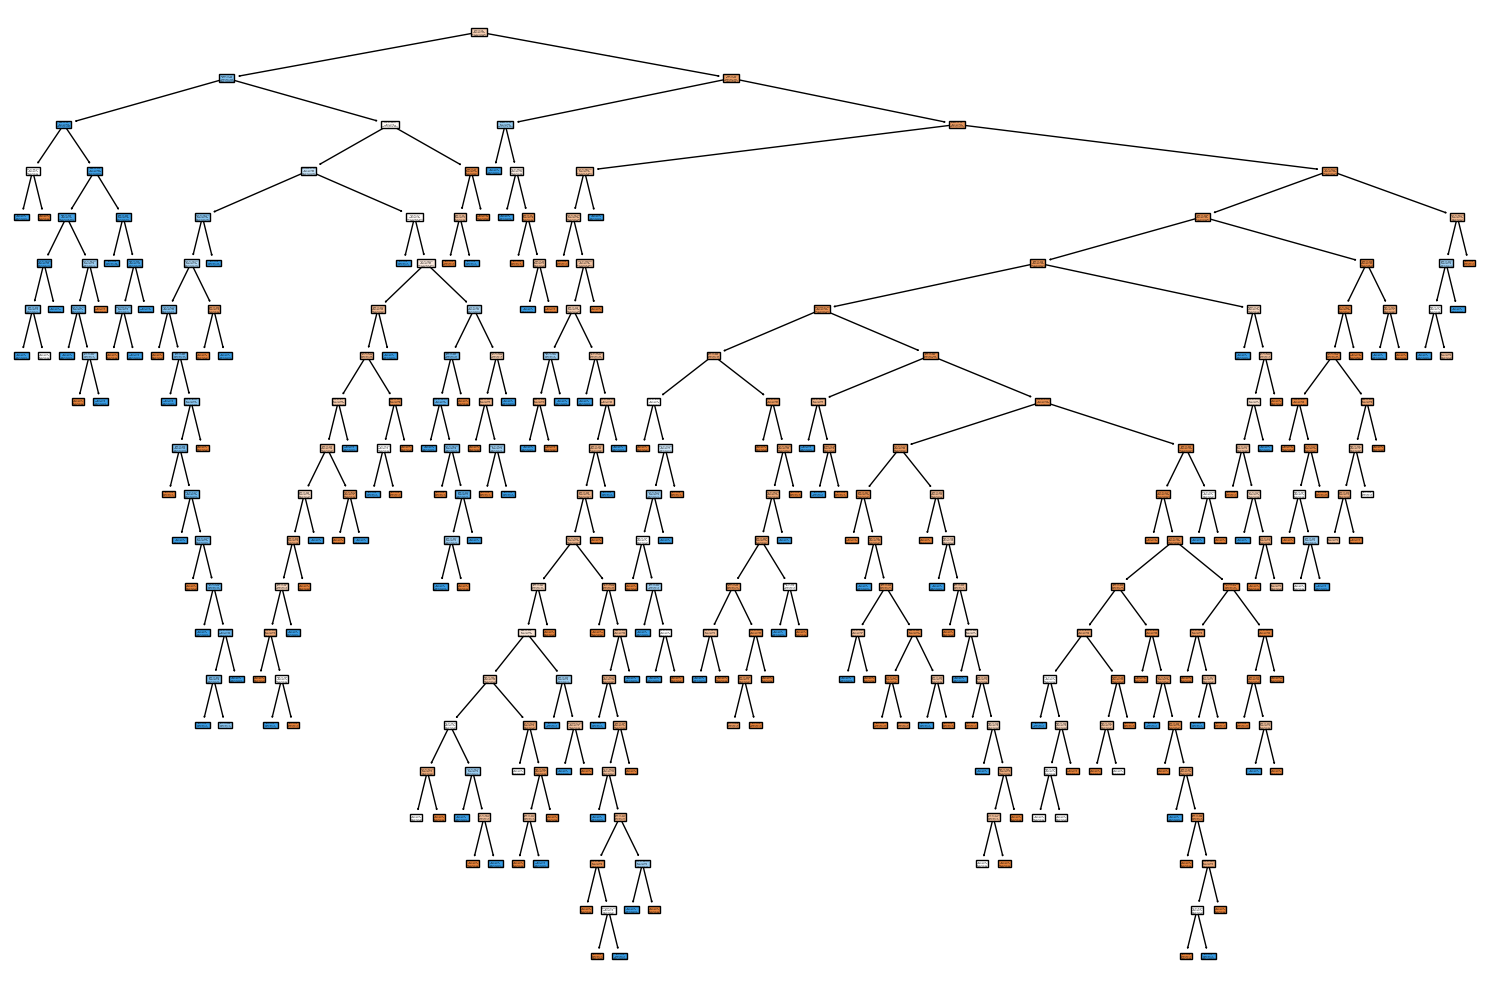

In [26]:
# Ploting Decision Tree 

plt.figure(figsize=(15,10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()

In [27]:
# Full Tree
full_tree = DecisionTreeClassifier()
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
# Post Pruning In Full Tree
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alpha)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.94231048e-04 8.99610781e-04 9.24769963e-04
 9.36329588e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.36329588e-04 9.88347898e-04 1.00253471e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.18841832e-03
 1.22566125e-03 1.22893258e-03 1.22893258e-03 1.24361593e-03
 1.24843945e-03 1.26404494e-03 1.27565833e-03 1.30996111e-03
 1.33761370e-03 1.37044603e-03 1.47927070e-03 1.51142557e-03
 1.54072312e-03 1.56675436e-03 1.60434338e-03 1.66892062e-03
 1.75561798e-03 1.86751451e-03 1.96629213e-03 2.10674157e-03
 2.17041916e-03 2.34082397e-03 2.41226470e-03 2.64273538e-03
 2.69412911e-03 3.43770913e-03 3.56327570e-03 5.47433606e-03
 9.05540038e-03 1.392950

In [34]:
# Train Model For All Alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)
    acc = full_tree.score(X_test,y_test)
    trees.append((model,alpha))

In [35]:
best_acc = 0
best_alpha = 0
for model,alpha in trees:
    curr_acc = model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [36]:
print(best_acc)

0.8379888268156425


In [37]:
print(best_alpha)

0.0015407231242023183


In [38]:
# Train Model For best_alpha

best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


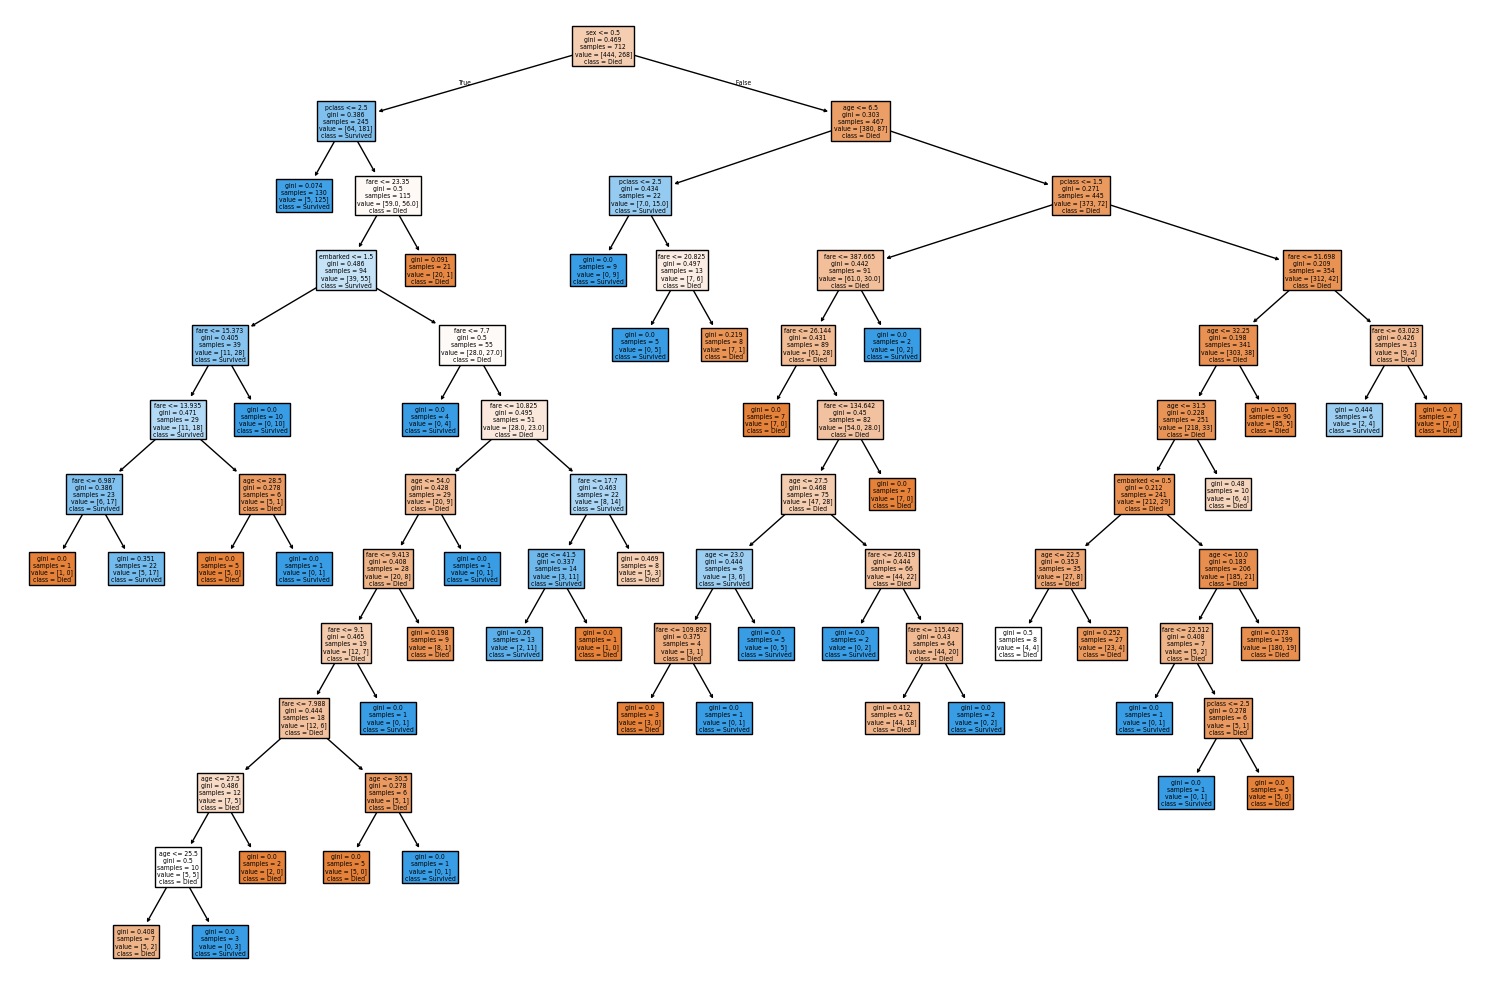

In [39]:
# Plot Best Decision Tree

plt.figure(figsize=(15,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()
plt.show()